In [1]:
import sys
sys.path.append('D:/cxr-triage')

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from src.data.dataset import ChestXrayDataset
from src.data.transforms import get_val_transforms
from src.models.densenet import DenseNetModel

LABELS = [
    'Atelectasis', 'Consolidation', 'Infiltration',
    'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis',
    'Effusion', 'Pneumonia', 'Pleural_Thickening',
    'Cardiomegaly', 'Nodule', 'Mass', 'Hernia'
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_ROOT = "F:/X ray dataset/Second Version"
CHECKPOINT_PATH = "D:/cxr-triage/checkpoints/clahe_320_logits_fix/best_model.pth"

model = DenseNetModel(num_classes=14, pretrained=False).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model — epoch {checkpoint['epoch']+1}, AUC {checkpoint['best_auc']:.4f}")

Loaded best model — epoch 15, AUC 0.7943


In [2]:
val_df = pd.read_csv('D:/cxr-triage/data/processed/val.csv')

val_transform = get_val_transforms(image_size=320, use_clahe=True)
val_dataset = ChestXrayDataset(csv_path=None, image_root=IMAGE_ROOT, transform=val_transform)
val_dataset.df = val_df

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

from tqdm import tqdm

all_logits = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Getting val logits"):
        images = images.to(DEVICE)
        with torch.amp.autocast('cuda'):
            logits = model(images)
        all_logits.append(logits.cpu().float())
        all_targets.append(targets.float())

val_logits = torch.cat(all_logits, dim=0)
val_targets = torch.cat(all_targets, dim=0)

print(f"Logits shape: {val_logits.shape}")
print(f"Targets shape: {val_targets.shape}")

Getting val logits: 100%|██████████| 1101/1101 [03:18<00:00,  5.54it/s]

Logits shape: torch.Size([17606, 14])
Targets shape: torch.Size([17606, 14])


In [3]:
import torch.nn as nn
import torch.optim as optim

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

temp_model = TemperatureScaler()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

def eval_loss():
    optimizer.zero_grad()
    scaled_logits = temp_model(val_logits)
    loss = criterion(scaled_logits, val_targets)
    loss.backward()
    return loss

optimizer.step(eval_loss)

print(f"Optimal Temperature: {temp_model.temperature.item():.4f}")

Optimal Temperature: 1.2142


In [4]:
test_df = pd.read_csv('D:/cxr-triage/data/processed/test.csv')

test_transform = get_val_transforms(image_size=320, use_clahe=True)
test_dataset = ChestXrayDataset(csv_path=None, image_root=IMAGE_ROOT, transform=test_transform)
test_dataset.df = test_df

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

all_logits = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Getting test logits"):
        images = images.to(DEVICE)
        with torch.amp.autocast('cuda'):
            logits = model(images)
        all_logits.append(logits.cpu().float())
        all_targets.append(targets.float())

test_logits = torch.cat(all_logits, dim=0)
test_targets = torch.cat(all_targets, dim=0)

print(f"Test logits shape: {test_logits.shape}")

Getting test logits: 100%|██████████| 1600/1600 [04:33<00:00,  5.84it/s]

Test logits shape: torch.Size([25596, 14])


In [5]:
def compute_ece(probs, targets, n_bins=10):
    """
    Computes Expected Calibration Error across all 14 findings combined.
    probs and targets are flattened across all classes for one overall ECE.
    """
    probs = probs.flatten().numpy()
    targets = targets.flatten().numpy()
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (probs > bin_lower) & (probs <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = targets[in_bin].mean()
            confidence_in_bin = probs[in_bin].mean()
            ece += np.abs(confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

print("ECE function ready")

ECE function ready


In [6]:
# Before calibration — plain sigmoid
probs_before = torch.sigmoid(test_logits)
ece_before = compute_ece(probs_before, test_targets)

# After calibration — temperature-scaled sigmoid
probs_after = torch.sigmoid(test_logits / temp_model.temperature.item())
ece_after = compute_ece(probs_after, test_targets)

print(f"ECE before calibration: {ece_before:.4f}")
print(f"ECE after calibration:  {ece_after:.4f}")
print(f"Improvement: {ece_before - ece_after:.4f}")

ECE before calibration: 0.4075
ECE after calibration:  0.4069
Improvement: 0.0005


In [7]:
# Check basic stats of probabilities
print("Probs before - min/max/mean:", probs_before.min().item(), probs_before.max().item(), probs_before.mean().item())
print("Targets - mean (overall positive rate):", test_targets.mean().item())

# Check ECE function on a sanity case: perfectly calibrated synthetic data
torch.manual_seed(0)
fake_probs = torch.rand(10000)
fake_targets = (torch.rand(10000) < fake_probs).float()
fake_ece = compute_ece(fake_probs, fake_targets)
print(f"\nSanity check ECE on synthetic perfectly-calibrated data: {fake_ece:.4f}")
print("(should be close to 0 if compute_ece function is correct)")

Probs before - min/max/mean: 4.2647468944778666e-05 0.9997584223747253 0.483375608921051
Targets - mean (overall positive rate): 0.07592146098613739

Sanity check ECE on synthetic perfectly-calibrated data: 0.0105
(should be close to 0 if compute_ece function is correct)


In [8]:
def compute_ece_per_class(probs, targets, n_bins=10):
    """Returns a dict of ECE per class."""
    ece_per_class = {}
    for i, label in enumerate(LABELS):
        ece_per_class[label] = compute_ece(probs[:, i:i+1], targets[:, i:i+1], n_bins=n_bins)
    return ece_per_class

ece_before_per_class = compute_ece_per_class(probs_before, test_targets)
ece_after_per_class = compute_ece_per_class(probs_after, test_targets)

print(f"{'Finding':<22} {'ECE Before':<14} {'ECE After':<14} {'Improvement':<12}")
print("-" * 65)
for label in LABELS:
    before = ece_before_per_class[label]
    after = ece_after_per_class[label]
    print(f"{label:<22} {before:<14.4f} {after:<14.4f} {before-after:<12.4f}")

print("-" * 65)
mean_ece_before = np.mean(list(ece_before_per_class.values()))
mean_ece_after = np.mean(list(ece_after_per_class.values()))
print(f"\nMean ECE before: {mean_ece_before:.4f}")
print(f"Mean ECE after:  {mean_ece_after:.4f}")

Finding                ECE Before     ECE After      Improvement 
-----------------------------------------------------------------
Atelectasis            0.4404         0.4299         0.0105      
Consolidation          0.5406         0.5243         0.0163      
Infiltration           0.4156         0.3917         0.0239      
Pneumothorax           0.4044         0.4038         0.0007      
Edema                  0.4013         0.4079         -0.0066     
Emphysema              0.3404         0.3544         -0.0140     
Fibrosis               0.4367         0.4436         -0.0069     
Effusion               0.3866         0.3788         0.0078      
Pneumonia              0.4556         0.4585         -0.0029     
Pleural_Thickening     0.4805         0.4774         0.0031      
Cardiomegaly           0.3261         0.3413         -0.0152     
Nodule                 0.4791         0.4729         0.0063      
Mass                   0.5081         0.4981         0.0099      
Hernia    

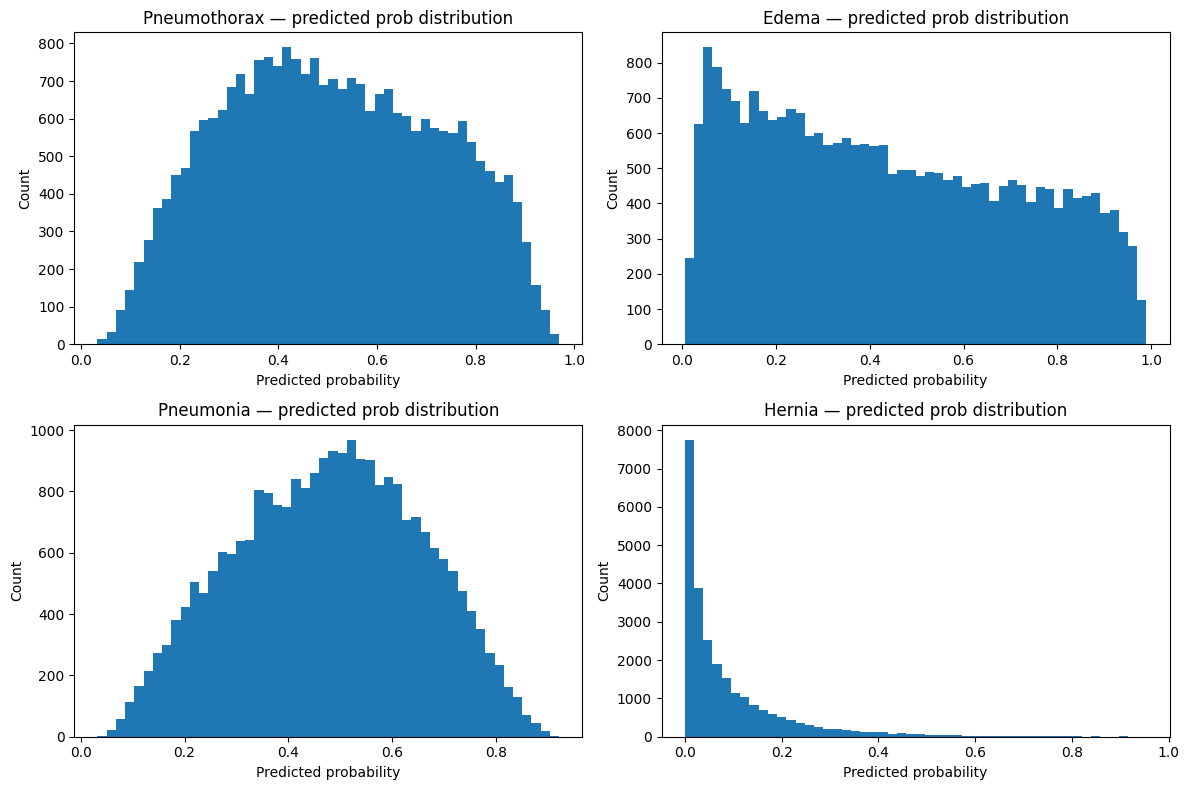

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Pick 4 example classes to visualize
for ax, label_idx, label_name in zip(axes.flat, [3, 4, 8, 13], ['Pneumothorax', 'Edema', 'Pneumonia', 'Hernia']):
    ax.hist(probs_before[:, label_idx].numpy(), bins=50)
    ax.set_title(f"{label_name} — predicted prob distribution")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig('D:/cxr-triage/notebooks/prob_distribution_check.png', dpi=100)
plt.show()

In [10]:
def fit_temperature_per_class(logits, targets, label_idx):
    """Fits a single temperature for one class only."""
    class_logits = logits[:, label_idx:label_idx+1]
    class_targets = targets[:, label_idx:label_idx+1]
    
    temp = nn.Parameter(torch.ones(1) * 1.5)
    optimizer = optim.LBFGS([temp], lr=0.01, max_iter=50)
    criterion = nn.BCEWithLogitsLoss()
    
    def closure():
        optimizer.zero_grad()
        scaled = class_logits / temp
        loss = criterion(scaled, class_targets)
        loss.backward()
        return loss
    
    optimizer.step(closure)
    return temp.item()

per_class_temps = {}
for i, label in enumerate(LABELS):
    t = fit_temperature_per_class(val_logits, val_targets, i)
    per_class_temps[label] = t
    print(f"{label:<22} T = {t:.4f}")

Atelectasis            T = 1.5024
Consolidation          T = 1.6514
Infiltration           T = 1.8460
Pneumothorax           T = 1.4758
Edema                  T = 1.1194
Emphysema              T = 1.4505
Fibrosis               T = 1.4037
Effusion               T = 1.4769
Pneumonia              T = 1.4722
Pleural_Thickening     T = 1.1789
Cardiomegaly           T = 1.0461
Nodule                 T = 1.7909
Mass                   T = 1.7554
Hernia                 T = 1.4437


In [11]:
# Apply per-class temperatures to test set
probs_after_per_class = torch.zeros_like(test_logits)
for i, label in enumerate(LABELS):
    t = per_class_temps[label]
    probs_after_per_class[:, i] = torch.sigmoid(test_logits[:, i] / t)

ece_after_per_class_calib = compute_ece_per_class(probs_after_per_class, test_targets)

print(f"{'Finding':<22} {'ECE Before':<14} {'ECE Global-T':<14} {'ECE Per-Class-T':<16}")
print("-" * 70)
for label in LABELS:
    before = ece_before_per_class[label]
    global_t = ece_after_per_class[label]
    per_class_t = ece_after_per_class_calib[label]
    print(f"{label:<22} {before:<14.4f} {global_t:<14.4f} {per_class_t:<16.4f}")

print("-" * 70)
mean_before = np.mean(list(ece_before_per_class.values()))
mean_global = np.mean(list(ece_after_per_class.values()))
mean_per_class = np.mean(list(ece_after_per_class_calib.values()))

print(f"\nMean ECE — No calibration:       {mean_before:.4f}")
print(f"Mean ECE — Global temperature:   {mean_global:.4f}")
print(f"Mean ECE — Per-class temperature: {mean_per_class:.4f}")

Finding                ECE Before     ECE Global-T   ECE Per-Class-T 
----------------------------------------------------------------------
Atelectasis            0.4404         0.4299         0.4199          
Consolidation          0.5406         0.5243         0.5018          
Infiltration           0.4156         0.3917         0.3500          
Pneumothorax           0.4044         0.4038         0.4030          
Edema                  0.4013         0.4079         0.4051          
Emphysema              0.3404         0.3544         0.3669          
Fibrosis               0.4367         0.4436         0.4483          
Effusion               0.3866         0.3788         0.3710          
Pneumonia              0.4556         0.4585         0.4613          
Pleural_Thickening     0.4805         0.4774         0.4778          
Cardiomegaly           0.3261         0.3413         0.3296          
Nodule                 0.4791         0.4729         0.4623          
Mass               

In [12]:
def compute_ece_v2(probs, targets, n_bins=15):
    """More standard ECE implementation using equal-width bins,
    explicitly handling the lower bound of bin 0."""
    probs = probs.flatten().numpy()
    targets = targets.flatten().numpy()
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total_samples = len(probs)
    
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i+1]
        if i == 0:
            in_bin = (probs >= lo) & (probs <= hi)
        else:
            in_bin = (probs > lo) & (probs <= hi)
        
        n_in_bin = in_bin.sum()
        if n_in_bin > 0:
            acc = targets[in_bin].mean()
            conf = probs[in_bin].mean()
            ece += (n_in_bin / total_samples) * abs(acc - conf)
    
    return ece

# Re-test on synthetic perfectly calibrated data
torch.manual_seed(0)
fake_probs = torch.rand(50000)
fake_targets = (torch.rand(50000) < fake_probs).float()
print("Sanity check v2:", compute_ece_v2(fake_probs, fake_targets))

# Re-check Pneumothorax specifically with more bins
pneumo_idx = LABELS.index('Pneumothorax')
ece_v2_before = compute_ece_v2(probs_before[:, pneumo_idx], test_targets[:, pneumo_idx])
print(f"Pneumothorax ECE v2 (before calib): {ece_v2_before:.4f}")

Sanity check v2: 0.005348991299495101
Pneumothorax ECE v2 (before calib): 0.4044


In [13]:
import json

calibration_results = {
    'global_temperature': temp_model.temperature.item(),
    'per_class_temperatures': per_class_temps,
    'ece': {
        'no_calibration': float(mean_before),
        'global_temperature': float(mean_global),
        'per_class_temperature': float(mean_per_class)
    },
    'conclusion': 'Limited ECE improvement due to aggressive pos_weight during training inducing broad probability distributions. AUC unaffected. Per-class temperature saved for inference use.'
}

with open('D:/cxr-triage/notebooks/calibration_results.json', 'w') as f:
    json.dump(calibration_results, f, indent=2)

print("Saved")

Saved
